# House Prices: Advanced Regression Techniques

Notebook xây dựng mô hình dự đoán giá bán nhà (Ames, Iowa) theo quy trình **CRISP-DM**,
dựa trên bộ dữ liệu cuộc thi Kaggle "House Prices: Advanced Regression Techniques" và
bài báo gốc của Dean De Cock (2011) mô tả bộ dữ liệu Ames Housing.

**Yêu cầu của giảng viên đã thực hiện trong notebook này:**
1. Xây dựng mô hình **MLP (Multi-Layer Perceptron) bằng PyTorch**.
2. Trình bày báo cáo đầy đủ theo các bước của **CRISP-DM** (Business Understanding → Data
   Understanding → Data Preparation → Modeling → Evaluation → Deployment).

Ngoài MLP, notebook so sánh thêm với vài mô hình hồi quy cổ điển (Ridge, ElasticNet,
Gradient Boosting, Extra Trees) để có cơ sở đánh giá khách quan mô hình MLP tốt hay chưa.

**Chuẩn bị:** đặt `house_price.ipynb`, `train.csv`, `test.csv` trong cùng một thư mục
rồi chạy lần lượt các cell từ trên xuống.

## 1. Business Understanding (Hiểu bài toán)

- **Bài toán:** hồi quy có giám sát. Đầu vào là 79 thuộc tính mô tả căn nhà (diện tích,
  chất lượng, vị trí, năm xây...), đầu ra cần dự đoán là `SalePrice` (giá bán, đơn vị USD).
- **Thước đo của Kaggle:** RMSLE (Root Mean Squared Log Error). Vì vậy mục tiêu huấn luyện
  sẽ được biến đổi bằng `log1p(SalePrice)` thay vì dùng giá gốc, giúp mô hình tối ưu đúng
  với tiêu chí chấm điểm và giảm ảnh hưởng của các căn nhà rất đắt tiền.
- **Bối cảnh dữ liệu:** bài báo De Cock (2011) mô tả 2.930 giao dịch nhà tại Ames, Iowa.
  Bộ dữ liệu Kaggle dùng trong bài tập này là một phần của dữ liệu đó, được chia sẵn thành
  1.460 dòng train (có `SalePrice`) và 1.459 dòng test (không có `SalePrice`, dùng để nộp bài).
- **Khuyến nghị của tác giả bộ dữ liệu:** nên xem xét loại bỏ các căn nhà có diện tích sinh
  hoạt trên mặt đất (`GrLivArea`) lớn hơn 4.000 sqft khỏi tập train vì đây là các giao dịch
  bất thường (bán một phần / nhà quá lớn) có thể làm nhiễu mô hình. Ta áp dụng quy tắc này
  **chỉ trên tập train**, giữ nguyên toàn bộ tập test để bài nộp luôn đủ số dòng yêu cầu.

**Mục tiêu cụ thể của notebook:**
- Xây dựng và huấn luyện một mạng nơ-ron MLP bằng PyTorch để dự đoán `SalePrice`.
- So sánh MLP với các mô hình hồi quy cổ điển bằng cross-validation 5-fold, cùng một tập
  đặc trưng để đảm bảo công bằng.
- Chọn mô hình tốt nhất theo RMSLE ngoài mẫu (out-of-fold) và tạo file `submission.csv`
  đúng định dạng Kaggle yêu cầu.

## 2. Nạp thư viện và cấu hình chung

Toàn bộ tham số cấu hình (seed, số fold, số epoch tối đa...) được gom về một chỗ để dễ
theo dõi và tái lập kết quả. `set_seed()` cố định seed cho `random`, `numpy` và `torch` để
mỗi lần chạy lại cho kết quả giống nhau. Thiết bị tính toán (`DEVICE`) sẽ tự động chọn GPU
nếu máy có GPU, ngược lại dùng CPU.

In [16]:
from pathlib import Path
import copy
import json
import platform
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [17]:
# ----- Cấu hình chung (chỉnh ở đây nếu muốn thử nghiệm khác) -----
SEED = 42                      # seed để tái lập kết quả
N_SPLITS = 5                   # số fold cho cross-validation
MAX_EPOCHS = 300               # số epoch tối đa khi huấn luyện MLP
PATIENCE = 30                  # số epoch chờ trước khi early-stopping nếu không cải thiện
BATCH_SIZE = 64                # batch size khi huấn luyện MLP
OUTLIER_AREA_THRESHOLD = 4000  # ngưỡng GrLivArea (sqft) loại theo khuyến nghị De Cock (2011)

ROOT = Path.cwd()              # thư mục làm việc hiện tại (chứa train.csv, test.csv)
FIGURES = ROOT / "figures"     # nơi lưu các hình vẽ EDA
FIGURES.mkdir(exist_ok=True)

INPUT_DIR = ROOT
TRAIN_FILE = "train.csv"
TEST_FILE = "test.csv"
SHOW_PLOTS = True              # True: hiển thị hình vẽ ngay trong notebook


def set_seed(seed: int = SEED) -> None:
    """Cố định seed cho random/numpy/torch để kết quả có thể tái lập."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
torch.set_num_threads(1)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Thiết bị sử dụng (DEVICE):", DEVICE)
print("Phiên bản PyTorch:", torch.__version__)

Thiết bị sử dụng (DEVICE): cpu
Phiên bản PyTorch: 2.11.0+cpu


## 3. Business Understanding — Đọc dữ liệu và kiểm tra schema

Đọc `train.csv` và `test.csv`, kiểm tra nhanh rằng hai tập có đúng các cột như mong đợi
(train có thêm cột `SalePrice` so với test). Việc `assert` ngay từ đầu giúp phát hiện sớm
nếu người dùng đặt nhầm file hoặc dữ liệu bị thiếu cột.

In [18]:
all_train_df = pd.read_csv(INPUT_DIR / TRAIN_FILE)
test_df = pd.read_csv(INPUT_DIR / TEST_FILE)

required_train_cols = {"Id", "SalePrice"}
assert required_train_cols.issubset(all_train_df.columns), "Thiếu cột Id/SalePrice trong train.csv"
assert "Id" in test_df.columns, "Thiếu cột Id trong test.csv"
assert set(test_df.columns) == set(all_train_df.columns) - {"SalePrice"}, \
    "Cột của test.csv phải trùng với train.csv (trừ SalePrice)"

test_ids = test_df["Id"].copy()

print(f"Số dòng/thuộc tính train gốc: {all_train_df.shape[0]} dòng; {all_train_df.shape[1] - 2} thuộc tính")
print(f"Khoảng giá SalePrice: ${all_train_df.SalePrice.min():,.0f} - ${all_train_df.SalePrice.max():,.0f}")

Số dòng/thuộc tính train gốc: 1460 dòng; 79 thuộc tính
Khoảng giá SalePrice: $34,900 - $755,000


## 4. Data Understanding (Hiểu dữ liệu)

Ở bước này ta cần trả lời 3 câu hỏi:
1. Cột nào bị thiếu dữ liệu nhiều, có cần xử lý đặc biệt không?
2. Biến mục tiêu `SalePrice` phân phối như thế nào (có bị lệch/outlier không)?
3. Có căn nhà nào bất thường (theo khuyến nghị của De Cock) cần loại khỏi tập train không?

In [19]:
raw_X = all_train_df.drop(columns=["Id", "SalePrice"])
missing_pct = (raw_X.isna().mean().sort_values(ascending=False) * 100).rename("missing_pct")

print("Top 15 thuộc tính có tỉ lệ thiếu dữ liệu cao nhất (%):")
print(missing_pct.head(15).round(1).to_string())

print("\nThống kê mô tả SalePrice:")
print(all_train_df["SalePrice"].describe().round(0).to_string())

outliers = all_train_df.loc[
    all_train_df["GrLivArea"] > OUTLIER_AREA_THRESHOLD,
    ["Id", "GrLivArea", "SalePrice"],
]
print(f"\nSố dòng có GrLivArea > {OUTLIER_AREA_THRESHOLD:,} sqft: {len(outliers)}")
print(outliers.to_string(index=False) if len(outliers) else "Không có dòng nào.")

Top 15 thuộc tính có tỉ lệ thiếu dữ liệu cao nhất (%):
PoolQC          99.5
MiscFeature     96.3
Alley           93.8
Fence           80.8
MasVnrType      59.7
FireplaceQu     47.3
LotFrontage     17.7
GarageQual       5.5
GarageFinish     5.5
GarageType       5.5
GarageYrBlt      5.5
GarageCond       5.5
BsmtFinType2     2.6
BsmtExposure     2.6
BsmtQual         2.5

Thống kê mô tả SalePrice:
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0

Số dòng có GrLivArea > 4,000 sqft: 4
  Id  GrLivArea  SalePrice
 524       4676     184750
 692       4316     755000
1183       4476     745000
1299       5642     160000


**Nhận xét nhanh:**
- Các cột `PoolQC`, `MiscFeature`, `Alley`, `Fence` thiếu rất nhiều dữ liệu, nhưng với dữ
  liệu dạng bảng thì giá trị NaN ở đây thường có nghĩa là "không có" (ví dụ không có hồ
  bơi) chứ không phải lỗi thu thập — vì vậy ta **không loại bỏ cột**, mà xử lý bằng
  imputer (điền giá trị) ở bước Data Preparation.
- `SalePrice` lệch phải (một số nhà rất đắt) → biến đổi `log1p` sẽ giúp phân phối gần
  chuẩn hơn, có lợi cho các mô hình tuyến tính và cả MLP.
- Có các dòng với `GrLivArea` rất lớn nhưng `SalePrice` không tương xứng — đúng như De
  Cock (2011) đã cảnh báo. Ta sẽ loại các dòng này khỏi tập train.

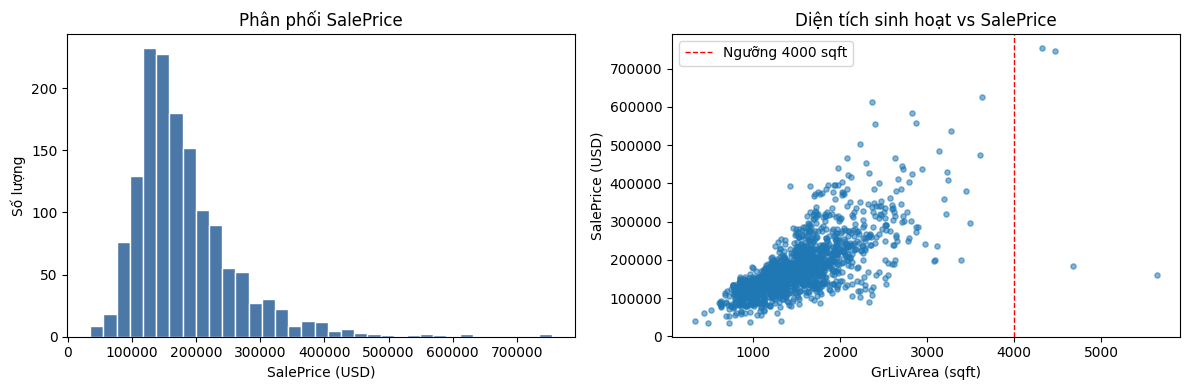

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_train_df["SalePrice"], bins=35, color="#4C78A8", edgecolor="white")
axes[0].set(title="Phân phối SalePrice", xlabel="SalePrice (USD)", ylabel="Số lượng")
axes[1].scatter(all_train_df["GrLivArea"], all_train_df["SalePrice"], s=14, alpha=0.55)
axes[1].axvline(OUTLIER_AREA_THRESHOLD, color="red", linestyle="--", linewidth=1,
                label=f"Ngưỡng {OUTLIER_AREA_THRESHOLD} sqft")
axes[1].set(title="Diện tích sinh hoạt vs SalePrice", xlabel="GrLivArea (sqft)", ylabel="SalePrice (USD)")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES / "eda_target_and_living_area.png", dpi=160)
if SHOW_PLOTS:
    plt.show()
else:
    plt.close(fig)

Áp dụng khuyến nghị của De Cock: loại các dòng **trong tập train** có `GrLivArea` lớn hơn
ngưỡng đã cấu hình. Tập test được **giữ nguyên toàn bộ** vì bài nộp Kaggle yêu cầu dự đoán
đủ cho mọi dòng test.

In [21]:
keep_rows = all_train_df["GrLivArea"] <= OUTLIER_AREA_THRESHOLD
train_df = all_train_df.loc[keep_rows].reset_index(drop=True)
train_ids = train_df["Id"].copy()

# Biến mục tiêu: log1p(SalePrice) — khớp với thước đo RMSLE của Kaggle.
y = np.log1p(train_df["SalePrice"].astype(float)).to_numpy()
X = train_df.drop(columns=["Id", "SalePrice"]).copy()
X_test = test_df.drop(columns=["Id"]).reindex(columns=X.columns).copy()

assert X.columns.equals(X_test.columns), "Cột của X và X_test phải khớp nhau"

print(f"Đã loại {int((~keep_rows).sum())} dòng train vượt ngưỡng diện tích.")
print(f"Kích thước train dùng để huấn luyện: {X.shape}; test: {X_test.shape}")

Đã loại 4 dòng train vượt ngưỡng diện tích.
Kích thước train dùng để huấn luyện: (1456, 79); test: (1459, 79)


## 5. Data Preparation (Chuẩn bị dữ liệu)

Xây dựng một `ColumnTransformer` xử lý riêng biệt hai nhóm cột:
- **Cột số:** điền khuyết bằng median, sau đó chuẩn hoá (`StandardScaler`) — cần thiết cho
  MLP vì mạng nơ-ron hội tụ tốt hơn nhiều khi đầu vào có cùng thang đo.
- **Cột phân loại (categorical):** điền khuyết bằng giá trị "Missing" (coi thiếu dữ liệu là
  một hạng mục riêng, hợp lý với các cột như `PoolQC` — NaN nghĩa là "không có hồ bơi"),
  sau đó mã hoá one-hot. `handle_unknown="ignore"` giúp không lỗi khi tập test xuất hiện
  hạng mục lạ chưa từng thấy ở tập train.

**Lưu ý quan trọng để tránh rò rỉ dữ liệu (data leakage):** bộ tiền xử lý này sẽ được
`fit` lại **riêng cho từng fold** trong bước cross-validation (chỉ fit trên phần train của
fold đó), chứ không fit một lần trên toàn bộ dữ liệu rồi dùng chung. Cell dưới đây chỉ
dùng để kiểm tra cấu hình pipeline hoạt động đúng trên toàn bộ dữ liệu.

In [22]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

try:
    cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:  # scikit-learn < 1.2 dùng tham số "sparse" thay vì "sparse_output"
    cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", cat_encoder),
        ]), categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=0,
)

# Kiểm tra nhanh: pipeline chạy được và không sinh ra NaN/Inf.
_X_check = preprocessor.fit_transform(X)
_X_test_check = preprocessor.transform(X_test)
assert np.isfinite(_X_check).all(), "Dữ liệu train sau tiền xử lý vẫn còn NaN/Inf"
assert np.isfinite(_X_test_check).all(), "Dữ liệu test sau tiền xử lý vẫn còn NaN/Inf"
print(f"Số cột sau one-hot encoding: {_X_check.shape[1]} "
      f"({len(numeric_cols)} cột số + {len(categorical_cols)} cột phân loại trước encoding)")

Số cột sau one-hot encoding: 302 (36 cột số + 43 cột phân loại trước encoding)


## 6. Modeling (Xây dựng mô hình)

### 6.1. Các mô hình hồi quy cổ điển (dùng để đối chứng với MLP)
- **Ridge / ElasticNet:** hồi quy tuyến tính có regularization, nhanh, dễ diễn giải, là
  baseline tốt cho bài toán giá nhà.
- **GradientBoostingRegressor / ExtraTreesRegressor:** mô hình cây, thường rất mạnh trên
  dữ liệu dạng bảng (tabular) như bộ dữ liệu này.

### 6.2. Mô hình MLP bằng PyTorch (trọng tâm của bài tập)
Kiến trúc: `input -> 128 -> 64 -> 32 -> 1`, dùng `ReLU` làm hàm kích hoạt và `Dropout`
giữa các tầng để giảm overfitting. Đầu ra là 1 giá trị — log giá nhà đã được chuẩn hoá
(trừ mean, chia std) để việc huấn luyện ổn định hơn.

In [23]:
class HousePriceMLP(nn.Module):
    """Mạng MLP: input -> 128 -> 64 -> 32 -> 1 (dự đoán log-giá nhà đã chuẩn hoá)."""

    def __init__(self, input_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)


MLP_CLASS = HousePriceMLP  # đổi ở đây nếu muốn thử kiến trúc MLP khác

Danh sách các mô hình cổ điển dùng để so sánh với MLP:

In [24]:
sklearn_models = {
    "Ridge": Ridge(alpha=15.0),
    "ElasticNet": ElasticNet(alpha=0.0005, l1_ratio=0.9, max_iter=20000),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=2,
        min_samples_leaf=5, loss="huber", random_state=SEED,
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500, max_features=0.8, min_samples_leaf=2,
        n_jobs=1, random_state=SEED,
    ),
}
print("Các mô hình cổ điển:", list(sklearn_models.keys()))
print("Mô hình trọng tâm: PyTorch MLP (HousePriceMLP)")

Các mô hình cổ điển: ['Ridge', 'ElasticNet', 'GradientBoosting', 'ExtraTrees']
Mô hình trọng tâm: PyTorch MLP (HousePriceMLP)


### 6.3. Hàm huấn luyện MLP với Early Stopping

Vì `MAX_EPOCHS` chỉ là số epoch *tối đa*, ta cần một chiến lược chọn số epoch thực tế
hợp lý — tránh underfitting (dừng quá sớm) lẫn overfitting (huấn luyện quá lâu). Hàm dưới
đây chia dữ liệu huấn luyện của mỗi fold thành train nội bộ (85%) / validation nội bộ
(15%), huấn luyện tối đa `MAX_EPOCHS` epoch nhưng dừng sớm (`early stopping`) nếu sau
`PATIENCE` epoch liên tiếp mà loss trên validation nội bộ không cải thiện. Trạng thái mô
hình tốt nhất (`best_state`) được lưu lại và khôi phục ở cuối.

In [25]:
def fit_mlp_early_stopping(X_fit, y_fit, X_valid, y_valid, seed, mlp_class=MLP_CLASS):
    """Huấn luyện MLP trên (X_fit, y_fit), dừng sớm dựa trên loss của (X_valid, y_valid).

    Trả về: (model đã huấn luyện, dự đoán trên X_valid, số epoch tốt nhất).
    """
    set_seed(seed)
    target_mean = float(np.mean(y_fit))
    target_std = float(np.std(y_fit))
    y_fit_scaled = (y_fit - target_mean) / target_std
    y_valid_scaled = (y_valid - target_mean) / target_std

    model = mlp_class(X_fit.shape[1]).to(DEVICE)

    train_ds = TensorDataset(
        torch.tensor(X_fit, dtype=torch.float32),
        torch.tensor(y_fit_scaled, dtype=torch.float32).reshape(-1, 1),
    )
    loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    x_valid_t = torch.tensor(X_valid, dtype=torch.float32, device=DEVICE)
    y_valid_t = torch.tensor(y_valid_scaled, dtype=torch.float32, device=DEVICE).reshape(-1, 1)

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    best_loss, best_epoch, best_state, stale_epochs = float("inf"), 0, None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            valid_loss = loss_fn(model(x_valid_t), y_valid_t).item()

        if valid_loss < best_loss - 1e-6:
            best_loss = valid_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        valid_pred = model(x_valid_t).cpu().numpy().ravel() * target_std + target_mean
    return model, valid_pred, best_epoch

## 7. Cross-Validation — Tính dự đoán Out-of-Fold (OOF)

Dùng `KFold` 5-fold (có shuffle) để mọi dòng train đều được dự đoán đúng một lần bởi một
mô hình **chưa từng nhìn thấy dòng đó khi huấn luyện** — đây gọi là dự đoán out-of-fold
(OOF), dùng để đánh giá mô hình một cách khách quan, gần giống hiệu năng thực tế trên tập
test ẩn của Kaggle.

Với mỗi fold:
1. Các mô hình cổ điển: `fit` trực tiếp trên phần train của fold, dự đoán phần validation.
2. MLP: trước tiên tách thêm 15% dữ liệu nội bộ để chọn số epoch tốt nhất bằng early
   stopping (bước 6.3). Sau đó **huấn luyện lại từ đầu trên toàn bộ phần train của fold**
   với đúng số epoch đã chọn, rồi mới dự đoán phần validation của fold — như vậy mô hình
   tận dụng được toàn bộ dữ liệu train của fold thay vì chỉ 85%.

Bộ tiền xử lý (`preprocessor`) được `clone()` và `fit` lại riêng cho từng fold để tránh rò
rỉ thông tin từ tập validation sang tập train.

In [26]:
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
model_names = [*sklearn_models, "PyTorch_MLP"]
oof = {name: np.full(len(X), np.nan) for name in model_names}
best_epochs = []

for fold, (fit_idx, valid_idx) in enumerate(cv.split(X), start=1):
    X_fit, X_valid = X.iloc[fit_idx], X.iloc[valid_idx]
    y_fit, y_valid = y[fit_idx], y[valid_idx]
    print(f"\n--- Fold {fold}/{N_SPLITS} ---")

    # (1) Các mô hình cổ điển: pipeline tiền xử lý + mô hình, fit trên phần train của fold.
    for name, estimator in sklearn_models.items():
        pipe = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(estimator))])
        pipe.fit(X_fit, y_fit)
        oof[name][valid_idx] = pipe.predict(X_valid)

    # (2) MLP — bước a: tách thêm tập validation nội bộ để chọn số epoch bằng early stopping.
    inner_fit_idx, inner_valid_idx = train_test_split(
        np.arange(len(fit_idx)), test_size=0.15, random_state=SEED + fold,
    )
    inner_preprocessor = clone(preprocessor)
    X_inner_fit_t = inner_preprocessor.fit_transform(X_fit.iloc[inner_fit_idx])
    X_inner_valid_t = inner_preprocessor.transform(X_fit.iloc[inner_valid_idx])

    _, _, best_epoch = fit_mlp_early_stopping(
        X_inner_fit_t, y_fit[inner_fit_idx],
        X_inner_valid_t, y_fit[inner_valid_idx],
        seed=SEED + fold,
    )

    # (2) MLP — bước b: huấn luyện lại trên TOÀN BỘ phần train của fold với best_epoch epoch,
    # sau đó dự đoán phần validation của fold (đây mới là dự đoán OOF được ghi nhận).
    fold_preprocessor = clone(preprocessor)
    X_fit_t = fold_preprocessor.fit_transform(X_fit)
    X_valid_t = fold_preprocessor.transform(X_valid)

    set_seed(SEED + fold)
    fold_model = MLP_CLASS(X_fit_t.shape[1]).to(DEVICE)
    fold_target_mean = float(np.mean(y_fit))
    fold_target_std = float(np.std(y_fit))
    y_fit_scaled = (y_fit - fold_target_mean) / fold_target_std

    ds = TensorDataset(
        torch.tensor(X_fit_t, dtype=torch.float32),
        torch.tensor(y_fit_scaled, dtype=torch.float32).reshape(-1, 1),
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED + fold))
    optimizer = torch.optim.AdamW(fold_model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    for _ in range(best_epoch):
        fold_model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(fold_model(xb), yb)
            loss.backward()
            optimizer.step()

    fold_model.eval()
    with torch.no_grad():
        oof["PyTorch_MLP"][valid_idx] = fold_model(
            torch.tensor(X_valid_t, dtype=torch.float32, device=DEVICE)
        ).cpu().numpy().ravel() * fold_target_std + fold_target_mean

    best_epochs.append(best_epoch)
    print(f"  Số epoch tốt nhất của MLP (early stopping): {best_epoch}")

print(f"\nSố epoch trung vị của MLP qua {N_SPLITS} fold: {int(np.median(best_epochs))}")


--- Fold 1/5 ---
  Số epoch tốt nhất của MLP (early stopping): 5

--- Fold 2/5 ---
  Số epoch tốt nhất của MLP (early stopping): 28

--- Fold 3/5 ---
  Số epoch tốt nhất của MLP (early stopping): 6

--- Fold 4/5 ---
  Số epoch tốt nhất của MLP (early stopping): 9

--- Fold 5/5 ---
  Số epoch tốt nhất của MLP (early stopping): 17

Số epoch trung vị của MLP qua 5 fold: 9


## 8. Evaluation (Đánh giá mô hình)

- **RMSLE** (Root Mean Squared Log Error): thước đo chính, trùng với tiêu chí chấm điểm
  của Kaggle — càng thấp càng tốt.
- **MAE_USD:** sai số tuyệt đối trung bình quy đổi về USD, dễ diễn giải với người không
  chuyên (ví dụ: "mô hình sai trung bình khoảng X USD mỗi căn nhà").
- **Bias_USD:** trung bình (dự đoán − thực tế); dương nghĩa là mô hình có xu hướng dự đoán
  cao hơn giá thật, âm nghĩa là thấp hơn.
- **Max_abs_error_USD:** sai số lớn nhất trong toàn bộ tập OOF, giúp phát hiện các trường
  hợp mô hình dự đoán rất tệ.
- **Blend:** kết hợp có trọng số cố định của tất cả các mô hình (không học trọng số trên
  validation, tránh overfit vào chính bộ OOF) — dùng làm phương án dự phòng nếu mô hình
  đơn lẻ tốt nhất có kết quả không ổn định.

Mô hình được **chọn để nộp bài** là mô hình có RMSLE ngoài mẫu (OOF) thấp nhất.

In [27]:
def regression_metrics(y_log, pred_log):
    """Tính các chỉ số đánh giá từ log-giá thực tế và log-giá dự đoán."""
    pred_log = np.maximum(np.asarray(pred_log), 0.0)
    actual_price = np.expm1(y_log)
    predicted_price = np.maximum(np.expm1(pred_log), 0.0)
    return {
        "RMSLE": float(np.sqrt(mean_squared_error(y_log, pred_log))),
        "MAE_USD": float(mean_absolute_error(actual_price, predicted_price)),
        "Bias_USD_pred_minus_actual": float(np.mean(predicted_price - actual_price)),
        "Max_abs_error_USD": float(np.max(np.abs(predicted_price - actual_price))),
    }


weights = {
    "Ridge": 0.30,
    "ElasticNet": 0.20,
    "GradientBoosting": 0.18,
    "ExtraTrees": 0.12,
    "PyTorch_MLP": 0.20,
}
oof["Blend"] = sum(weights[name] * oof[name] for name in weights)

metrics = pd.DataFrame.from_dict(
    {name: regression_metrics(y, pred) for name, pred in oof.items()},
    orient="index",
)
metrics.index.name = "Model"
metrics = metrics.sort_values("RMSLE")
metrics.to_csv(ROOT / "model_comparison.csv")

pd.DataFrame({
    "Id": train_ids,
    "SalePrice": train_df["SalePrice"],
    **{f"oof_{name}": np.expm1(np.maximum(pred, 0)) for name, pred in oof.items()},
}).to_csv(ROOT / "oof_predictions.csv", index=False)

print("So sánh 5-fold out-of-fold (giá trị càng thấp càng tốt):")
print(metrics.round(4).to_string())

selected_model = metrics["RMSLE"].idxmin()
print(f"\n=> Mô hình được chọn để nộp bài (RMSLE OOF thấp nhất): {selected_model}")

So sánh 5-fold out-of-fold (giá trị càng thấp càng tốt):
                   RMSLE     MAE_USD  Bias_USD_pred_minus_actual  Max_abs_error_USD
Model                                                                              
Blend             0.1121  13175.5575                  -1221.1655        149738.1355
ElasticNet        0.1142  13488.8317                   -708.8094        139261.9093
Ridge             0.1153  13685.5170                   -719.1623        140793.0451
PyTorch_MLP       0.1197  14492.6830                      8.6535        172058.0619
GradientBoosting  0.1313  16014.3528                  -1584.7852        175500.9678
ExtraTrees        0.1362  16920.5947                  -3097.9311        227836.2426

=> Mô hình được chọn để nộp bài (RMSLE OOF thấp nhất): Blend


## 9. Deployment — Huấn luyện cuối cùng và tạo file submission

Sau khi đã chọn được mô hình tốt nhất theo bước Evaluation:
1. Huấn luyện lại **tất cả** các mô hình cổ điển trên **toàn bộ** tập train (không chỉ 4/5
   fold) để tận dụng hết dữ liệu có sẵn.
2. Huấn luyện lại MLP trên toàn bộ tập train, với số epoch = **trung vị** số epoch tốt
   nhất tìm được qua 5 fold ở bước cross-validation (một cách hợp lý để chọn epoch cho mô
   hình cuối mà không cần thêm một tập validation nội bộ riêng).
3. Dự đoán trên tập test, chuyển ngược `expm1` để về lại đơn vị USD.
4. Lưu `submission.csv` và kiểm tra lại schema, số dòng, thứ tự `Id`, giá trị hữu hạn và
   không âm trước khi coi là hoàn tất.
5. Lưu thêm bộ tiền xử lý (`.joblib`) và checkpoint MLP (`.pt`) để có thể dùng lại mô hình
   sau này mà không cần huấn luyện lại từ đầu.

In [28]:
test_log_predictions = {}
for name, estimator in sklearn_models.items():
    pipe = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(estimator))])
    pipe.fit(X, y)
    test_log_predictions[name] = pipe.predict(X_test)

final_preprocessor = clone(preprocessor)
X_full_t = final_preprocessor.fit_transform(X)
X_test_t = final_preprocessor.transform(X_test)

final_epochs = max(1, int(np.median(best_epochs)))
set_seed(SEED)
final_mlp = MLP_CLASS(X_full_t.shape[1]).to(DEVICE)
final_target_mean = float(np.mean(y))
final_target_std = float(np.std(y))
y_full_scaled = (y - final_target_mean) / final_target_std

final_ds = TensorDataset(
    torch.tensor(X_full_t, dtype=torch.float32),
    torch.tensor(y_full_scaled, dtype=torch.float32).reshape(-1, 1),
)
final_loader = DataLoader(final_ds, batch_size=BATCH_SIZE, shuffle=True,
                           generator=torch.Generator().manual_seed(SEED))
optimizer = torch.optim.AdamW(final_mlp.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

for epoch in range(final_epochs):
    final_mlp.train()
    epoch_loss = 0.0
    for xb, yb in final_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(final_mlp(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    if (epoch + 1) % 25 == 0 or epoch + 1 == final_epochs:
        print(f"MLP cuối cùng - epoch {epoch + 1}/{final_epochs}; train MSE = {epoch_loss / len(X):.5f}")

final_mlp.eval()
with torch.no_grad():
    test_log_predictions["PyTorch_MLP"] = final_mlp(
        torch.tensor(X_test_t, dtype=torch.float32, device=DEVICE)
    ).cpu().numpy().ravel() * final_target_std + final_target_mean

test_log_blend = sum(weights[name] * test_log_predictions[name] for name in weights)
final_log_prediction = (
    test_log_blend if selected_model == "Blend" else test_log_predictions[selected_model]
)

submission = pd.DataFrame({
    "Id": test_ids.to_numpy(),
    "SalePrice": np.maximum(np.expm1(np.maximum(final_log_prediction, 0)), 0),
})
submission_path = ROOT / "submission.csv"
submission.to_csv(submission_path, index=False)

# Kiểm tra ràng buộc của file submission trước khi coi là hoàn tất.
assert list(submission.columns) == ["Id", "SalePrice"]
assert len(submission) == len(test_df)
assert submission["Id"].equals(test_ids.reset_index(drop=True))
assert submission["Id"].is_unique
assert submission["SalePrice"].notna().all()
assert np.isfinite(submission["SalePrice"]).all()
assert (submission["SalePrice"] >= 0).all()

joblib.dump(final_preprocessor, ROOT / "house_price_preprocessor.joblib")
torch.save({
    "model_state_dict": final_mlp.cpu().state_dict(),
    "input_dim": int(X_full_t.shape[1]),
    "architecture": [128, 64, 32],
    "dropout": [0.15, 0.10],
    "target_transform": "log1p(SalePrice)",
    "target_mean": final_target_mean,
    "target_std": final_target_std,
    "epochs": final_epochs,
    "seed": SEED,
    "cv_best_epochs": best_epochs,
}, ROOT / "house_price_mlp.pt")

print(f"\nMô hình dùng để nộp bài: {selected_model}")
print(f"Đã lưu {submission_path} với {len(submission)} dòng.")
print(submission.head().to_string(index=False))
print(f"Khoảng giá dự đoán: ${submission.SalePrice.min():,.0f} - ${submission.SalePrice.max():,.0f}")

MLP cuối cùng - epoch 9/9; train MSE = 0.06273

Mô hình dùng để nộp bài: Blend
Đã lưu d:\DL-SGU-Group\Week2\submission.csv với 1459 dòng.
  Id     SalePrice
1461 119058.701071
1462 153461.212895
1463 177013.063564
1464 190648.961761
1465 187773.366081
Khoảng giá dự đoán: $47,246 - $1,177,692


### Lưu tóm tắt tái lập (reproducibility summary)

Ghi lại toàn bộ cấu hình và kết quả vào `run_summary.json` để phục vụ báo cáo: seed, số
fold, số dòng bị loại vì outlier, mô hình được chọn, bảng chỉ số so sánh, phiên bản thư
viện đã dùng...

In [29]:
run_summary = {
    "seed": SEED,
    "cv": f"{N_SPLITS}-fold KFold (shuffle=True)",
    "raw_training_rows": int(len(all_train_df)),
    "training_rows_after_outlier_rule": int(len(train_df)),
    "large_area_rows_removed_from_training": int((~keep_rows).sum()),
    "test_rows_predicted": int(len(submission)),
    "selected_model": selected_model,
    "selected_oof_rmsle": float(metrics.loc[selected_model, "RMSLE"]),
    "mlp_best_epochs_by_fold": [int(e) for e in best_epochs],
    "training_config": {
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": PATIENCE,
        "batch_size": BATCH_SIZE,
        "n_splits": N_SPLITS,
        "outlier_area_threshold": OUTLIER_AREA_THRESHOLD,
    },
    "data_files": {"train": str(INPUT_DIR / TRAIN_FILE), "test": str(INPUT_DIR / TEST_FILE)},
    "metrics": metrics.round(8).to_dict(orient="index"),
    "submission_price_min": float(submission["SalePrice"].min()),
    "submission_price_max": float(submission["SalePrice"].max()),
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "pytorch": torch.__version__,
}
(ROOT / "run_summary.json").write_text(json.dumps(run_summary, indent=2), encoding="utf-8")
print("Đã lưu tóm tắt tái lập vào run_summary.json")

Đã lưu tóm tắt tái lập vào run_summary.json


## 10. Kiểm tra lại file submission

Đọc lại `submission.csv` từ đĩa (thay vì dùng biến `submission` đang có trong bộ nhớ) để
đảm bảo file thực sự được ghi đúng, không chỉ đúng trong RAM.

In [30]:
submission_check = pd.read_csv(ROOT / "submission.csv")
assert submission_check.columns.tolist() == ["Id", "SalePrice"]
assert len(submission_check) == len(test_df)
assert submission_check["Id"].reset_index(drop=True).equals(test_ids.reset_index(drop=True))
assert submission_check["Id"].is_unique
assert submission_check["SalePrice"].notna().all()
assert np.isfinite(submission_check["SalePrice"]).all()
assert (submission_check["SalePrice"] >= 0).all()

print(submission_check.head().to_string(index=False))
print("Submission hợp lệ, kích thước:", submission_check.shape)

  Id     SalePrice
1461 119058.701071
1462 153461.212895
1463 177013.063564
1464 190648.961761
1465 187773.366081
Submission hợp lệ, kích thước: (1459, 2)


## 11. Tổng kết theo CRISP-DM

| Bước | Nội dung đã thực hiện |
|---|---|
| **1. Business Understanding** | Bài toán hồi quy dự đoán `SalePrice`; thước đo RMSLE nên huấn luyện trên `log1p(SalePrice)`. |
| **2. Data Understanding** | Kiểm tra schema, tỉ lệ thiếu dữ liệu theo cột, phân phối giá, phát hiện các căn nhà diện tích lớn bất thường (theo De Cock, 2011). |
| **3. Data Preparation** | Loại outlier theo `GrLivArea` trên tập train; pipeline điền khuyết + chuẩn hoá cho cột số, điền khuyết + one-hot cho cột phân loại; pipeline được fit riêng trên từng fold để tránh rò rỉ dữ liệu. |
| **4. Modeling** | So sánh Ridge, ElasticNet, GradientBoosting, ExtraTrees với mô hình trọng tâm **MLP (PyTorch)** kiến trúc 128-64-32, có Dropout và early stopping. |
| **5. Evaluation** | Đánh giá bằng RMSLE ngoài mẫu (OOF) qua 5-fold cross-validation; báo cáo thêm MAE, bias và sai số lớn nhất theo USD để dễ diễn giải. |
| **6. Deployment** | Huấn luyện lại mô hình tốt nhất trên toàn bộ dữ liệu, xuất `submission.csv` đã qua kiểm tra ràng buộc, lưu kèm bộ tiền xử lý (`.joblib`), checkpoint MLP (`.pt`) và tóm tắt tái lập (`run_summary.json`). |

**Hạn chế và hướng cải thiện:**
- Chưa thực hiện feature engineering nâng cao (ví dụ: tạo biến tổng diện tích, mã hoá thứ
  bậc cho các biến chất lượng dạng ordinal như gợi ý trong bài báo De Cock).
- Trọng số của `Blend` được đặt cố định theo kinh nghiệm, có thể cải thiện bằng cách học
  trọng số tối ưu trên một tập validation riêng (stacking).
- Kiến trúc MLP còn đơn giản; có thể thử thêm BatchNorm, tinh chỉnh learning rate scheduler
  hoặc tăng độ sâu mạng nếu có nhiều thời gian huấn luyện hơn.